In [30]:
import pandas as pd
import numpy as np
import seaborn as sns

In [33]:
from sqlalchemy.orm import Session
from sqlalchemy import select
from sqlalchemy import Table 
from backend.models import Product, Size, SizeParameter
from sqlalchemy import create_engine

In [34]:
SQLITE_FILE_NAME = "./backend/nexa.db"
DATABASE_URL = f"sqlite:///{SQLITE_FILE_NAME}"
engine = create_engine(DATABASE_URL)
products = pd.read_sql_table('product', engine)
# df = pd.read_sql_query('SELECT * FROM product JOIN size ON product.id = size.product_id JOIN SizeParameter ON size.id = SizeParameter.size_id', engine)
sizes = pd.read_sql_table('size', engine)
size_parameters = pd.read_sql_table('sizeparameter', engine)

AttributeError: 'OptionEngine' object has no attribute 'execute'

In [74]:
engine = create_engine(DATABASE_URL)
df = pd.DataFrame()
# Create a session
with Session(engine) as session:
    statement = (
        select(Product, Size, SizeParameter)
        .join(Size, Product.id == Size.product_id)
        .join(SizeParameter, Size.id == SizeParameter.size_id)
    )
    results = session.execute(statement)
    df = pd.DataFrame(results)
    # for product, size, size_parameter in results:
        # print(f"Product: {product.name}, Size: {size.size_label}, Parameter: {size_parameter.parameter_name} = {size_parameter.parameter_value}")

In [77]:
dtype(results)

NameError: name 'dtype' is not defined

In [26]:
products = pd.read_csv('dump/products.csv', index_col='id')
sizes = pd.read_csv('dump/sizes.csv')
size_parameters = pd.read_csv('dump/size_parameters.csv')

In [27]:
products.head()

,Unnamed: 0,id,url,image_url,price,name,properties
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit..."
1,1,2,https://www.hemden.de/marvelis-modern-fit-hemd...,https://cdn.hemden.de/media/image/10/ec/00/470...,39.95,"Marvelis Modern Fit Hemd weiss, Einfarbig","{'Marke': 'Marvelis', 'Schnitt': 'Leicht taill..."
2,2,3,https://www.hemden.de/olymp-luxor-modern-fit-h...,https://cdn.hemden.de/media/image/10/89/79/635...,59.95,"OLYMP Luxor Modern Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Uni-Popeline', 'S..."
3,3,4,https://www.hemden.de/olymp-luxor-modern-fit-h...,https://cdn.hemden.de/media/image/5c/a3/96/030...,59.95,"OLYMP Luxor Modern Fit Hemd bleu, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Chambray', 'Nachh..."
4,4,5,https://www.hemden.de/marvelis-comfort-fit-hem...,https://cdn.hemden.de/media/image/60/41/da/795...,39.95,"Marvelis Comfort Fit Hemd bleu, Einfarbig","{'Marke': 'Marvelis', 'Schnitt': 'Gerader Schn..."


In [19]:
joined_products = products.join(sizes.set_index('product_id'), on='id', rsuffix='_size').join(size_parameters.set_index('size_id'), on='id_size', rsuffix='_size_parameters')
joined_products.drop(columns=['id_size', 'id_size_parameters'])

,Unnamed: 0,id,url,image_url,price,name,properties,Unnamed: 0_size,size_label,Unnamed: 0_size_parameters,parameter_name,parameter_value
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit...",0.0,XS,0.0,Kragenweite,36.0
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit...",0.0,XS,1.0,Oberweite,98.0
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit...",0.0,XS,2.0,Taillenweite,86.0
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit...",0.0,XS,3.0,Rückenbreite,38.0
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit...",0.0,XS,4.0,Hemdenlänge:,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
291,291,292,https://www.hemden.de/jacques-britt-galahemd-s...,https://cdn.hemden.de/media/image/59/4c/b4/960...,109.95,"Jacques Britt Galahemd Slim Fit - weiss, Einfa...","{'Marke': 'Jacques Britt', 'Schnitt': 'Taillie...",2466.0,6XL,17210.0,Oberweite,NaN
291,291,292,https://www.hemden.de/jacques-britt-galahemd-s...,https://cdn.hemden.de/media/image/59/4c/b4/960...,109.95,"Jacques Britt Galahemd Slim Fit - weiss, Einfa...","{'Marke': 'Jacques Britt', 'Schnitt': 'Taillie...",2466.0,6XL,17211.0,Taillenweite,NaN
291,291,292,https://www.hemden.de/jacques-britt-galahemd-s...,https://cdn.hemden.de/media/image/59/4c/b4/960...,109.95,"Jacques Britt Galahemd Slim Fit - weiss, Einfa...","{'Marke': 'Jacques Britt', 'Schnitt': 'Taillie...",2466.0,6XL,17212.0,Hemdenlänge:,NaN
291,291,292,https://www.hemden.de/jacques-britt-galahemd-s...,https://cdn.hemden.de/media/image/59/4c/b4/960...,109.95,"Jacques Britt Galahemd Slim Fit - weiss, Einfa...","{'Marke': 'Jacques Britt', 'Schnitt': 'Taillie...",2466.0,6XL,17213.0,bei Armlänge normal,NaN


In [16]:
joined_products.head()

,Unnamed: 0,id,url,image_url,price,name,properties,Unnamed: 0_size,id_size,size_label,Unnamed: 0_size,id_size,parameter_name,parameter_value
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit...",0.0,1.0,XS,0.0,1.0,Kragenweite,36.0
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit...",0.0,1.0,XS,1.0,2.0,Oberweite,98.0
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit...",0.0,1.0,XS,2.0,3.0,Taillenweite,86.0
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit...",0.0,1.0,XS,3.0,4.0,Rückenbreite,38.0
0,0,1,https://www.hemden.de/olymp-level-five-body-fi...,https://cdn.hemden.de/media/image/8f/68/4e/609...,59.95,"OLYMP Level Five Body Fit Hemd weiss, Einfarbig","{'Marke': 'OLYMP', 'Stoff': 'Stretch', 'Schnit...",0.0,1.0,XS,4.0,5.0,Hemdenlänge:,NaN


In [3]:
sizes.pivot(index='product_id', columns='size_label', values='id')

size_label,3XL,4XL,5XL,6XL,7XL,L,M,S,Unnamed: 10,Unnamed: 9,XL,XS,XXL
product_id,,,,,,,,,,,,,
1,7.0,8.0,9.0,10.0,NaN,4.0,3.0,2.0,NaN,NaN,5.0,1.0,6.0
2,17.0,18.0,19.0,20.0,NaN,14.0,13.0,12.0,NaN,NaN,15.0,11.0,16.0
3,27.0,28.0,29.0,30.0,NaN,24.0,23.0,22.0,NaN,NaN,25.0,21.0,26.0
4,37.0,38.0,39.0,40.0,NaN,34.0,33.0,32.0,NaN,NaN,35.0,31.0,36.0
5,47.0,48.0,49.0,50.0,NaN,44.0,43.0,42.0,NaN,NaN,45.0,41.0,46.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,2424.0,2425.0,2426.0,2427.0,NaN,2421.0,2420.0,2419.0,NaN,NaN,2422.0,2418.0,2423.0
288,2434.0,2435.0,2436.0,2437.0,NaN,2431.0,2430.0,2429.0,NaN,NaN,2432.0,2428.0,2433.0
289,2444.0,2445.0,2446.0,2447.0,NaN,2441.0,2440.0,2439.0,NaN,NaN,2442.0,2438.0,2443.0


In [4]:
size_parameters.head()

,Unnamed: 0,id,size_id,parameter_name,parameter_value
0,0,1,1,Kragenweite,36.0
1,1,2,1,Oberweite,98.0
2,2,3,1,Taillenweite,86.0
3,3,4,1,Rückenbreite,38.0
4,4,5,1,Hemdenlänge:,NaN


In [5]:
p_size_parameters = size_parameters.pivot(index='size_id', columns='parameter_name', values='parameter_value')
p_size_parameters.head(30)

parameter_name,Hemdenlänge:,Hüftweite,Kragenweite,"Kragenweite, cm",Oberweite,"Oberweite, cm",Rückenbreite,Rückenlänge,Schulterbreite,Taillenweite,"Taillenweite, cm",bei Armlänge extra kurz,bei Armlänge extra lang,bei Armlänge normal
size_id,,,,,,,,,,,,,,
1,NaN,NaN,36.0,NaN,98.0,NaN,38.0,NaN,NaN,86.0,NaN,76.0,79.0,76.0
2,NaN,NaN,37.5,NaN,104.0,NaN,40.0,NaN,NaN,92.0,NaN,78.0,81.0,78.0
3,NaN,NaN,39.5,NaN,110.0,NaN,42.0,NaN,NaN,98.0,NaN,80.0,83.0,80.0
4,NaN,NaN,41.5,NaN,116.0,NaN,44.0,NaN,NaN,104.0,NaN,80.0,83.0,80.0
5,NaN,NaN,43.5,NaN,124.0,NaN,46.0,NaN,NaN,112.0,NaN,83.0,87.0,83.0
6,NaN,NaN,45.5,NaN,132.0,NaN,48.0,NaN,NaN,120.0,NaN,85.0,89.0,85.0
7,NaN,NaN,47.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,49.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,52.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
p_size_parameters.isna().mean().sort_values()

parameter_name
Kragenweite                0.020268
Oberweite                  0.353060
Taillenweite               0.353060
bei Armlänge normal        0.361167
bei Armlänge extra lang    0.507499
Rückenbreite               0.699635
bei Armlänge extra kurz    0.703689
Schulterbreite             0.846372
Hüftweite                  0.896230
Kragenweite, cm            0.988650
Oberweite, cm              0.988650
Rückenlänge                0.988650
Taillenweite, cm           0.988650
Hemdenlänge:               1.000000
dtype: float64

<Axes: xlabel='bei Armlänge extra lang', ylabel='Oberweite'>

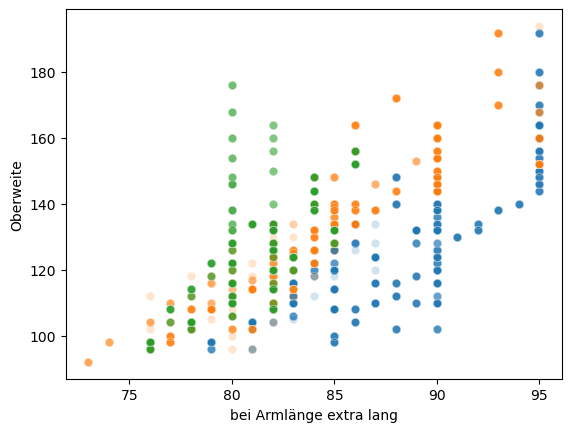

In [7]:
sns.scatterplot(p_size_parameters, x='bei Armlänge extra lang', y='Oberweite', alpha=0.2)
sns.scatterplot(p_size_parameters, x='bei Armlänge normal', y='Oberweite', alpha=0.2)
sns.scatterplot(p_size_parameters, x='bei Armlänge extra kurz', y='Oberweite', alpha=0.2)

<Axes: xlabel='bei Armlänge extra lang', ylabel='Kragenweite'>

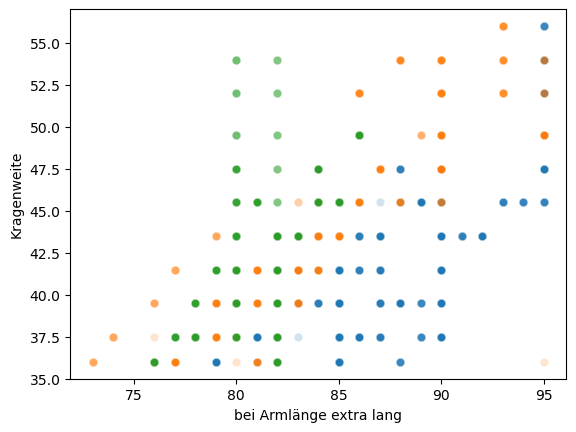

In [8]:
sns.scatterplot(p_size_parameters, x='bei Armlänge extra lang', y='Kragenweite', alpha=0.2)
sns.scatterplot(p_size_parameters, x='bei Armlänge normal', y='Kragenweite', alpha=0.2)
sns.scatterplot(p_size_parameters, x='bei Armlänge extra kurz', y='Kragenweite', alpha=0.2)

Overall it appears like at sleeve lengths below 90cm there is abundant choice. Above above 90 cm, width offering is significantly restricted towards the lower ranges. The step from 90 to 95 appears quite striking, as a similar trend is not observable for the other sizes.